# 상관 분석

- 금, 은, 달러의 상관성 분석

In [ ]:
# 필요한 패키지 설치
# uv add openpyxl

# excel 파일과 csv 파일의 차이? 데이터 공간 차지, 즉 비용과 관련 있다.
# excel은 메모장에서 열리지 X -> Binary File --> 같은 데이터여도 더 많은 저장 공간 차지
# CSV 파일은 아스키 코드로 저장 가능하여 메모장에서 열림. 즉, 메모리에 올릴 때 저장 공간 덜 차지.
# 파케이트라는 방식은 빅 데이터에서 데이터 저장 방식으로 메모리 더 더욱 더 덜 차지.

In [1]:
import pandas as pd

In [3]:
df = pd.read_excel('datas2/일별_금은달러.xlsx')

In [4]:
df.head()

,일자,금값,은값,달러 환율
0,2020.08.07,78538.90,27.53,1188.5
1,2020.08.06,78009.22,28.39,1185.5
2,2020.08.05,77748.00,26.88,1188.0
3,2020.08.04,75873.57,26.01,1194.5
4,2020.08.03,75761.76,24.39,1195.7


In [ ]:
df.sort_values(by = '일자')
# df.sort_values(by = '일자', inplace = True) inplace를 넣으면 원본을 수정해버린다.

,일자,금값,은값,달러 환율
27,2020.06.30,68559.78,18.54,1203.0
26,2020.07.01,68941.28,18.13,1203.5
25,2020.07.02,68278.07,18.24,1199.0
24,2020.07.06,68269.27,18.50,1194.0
23,2020.07.07,68443.14,18.63,1197.0
22,2020.07.08,69184.17,19.08,1195.0
21,2020.07.09,69748.21,18.88,1195.0
20,2020.07.10,69735.18,18.98,1201.0
19,2020.07.13,69933.64,19.71,1203.0
18,2020.07.14,69827.02,19.45,1206.5


In [9]:
# 그래프 기본 설정
from matplotlib import pyplot as plt
import numpy as np

# plt.rcParams["font.family"] = 'Malgun Gothic'  # 윈도우 환경
# 아래 두 줄을 그래프 시각화에서 복붙할 것.
plt.rcParams["font.family"] = 'NanumGothic'      # WSL ubuntu 환경
plt.rcParams['axes.unicode_minus'] = False       # 음수값 처리

plt.rcParams["font.size"] = 20
plt.rcParams["figure.figsize"] = (10, 8)

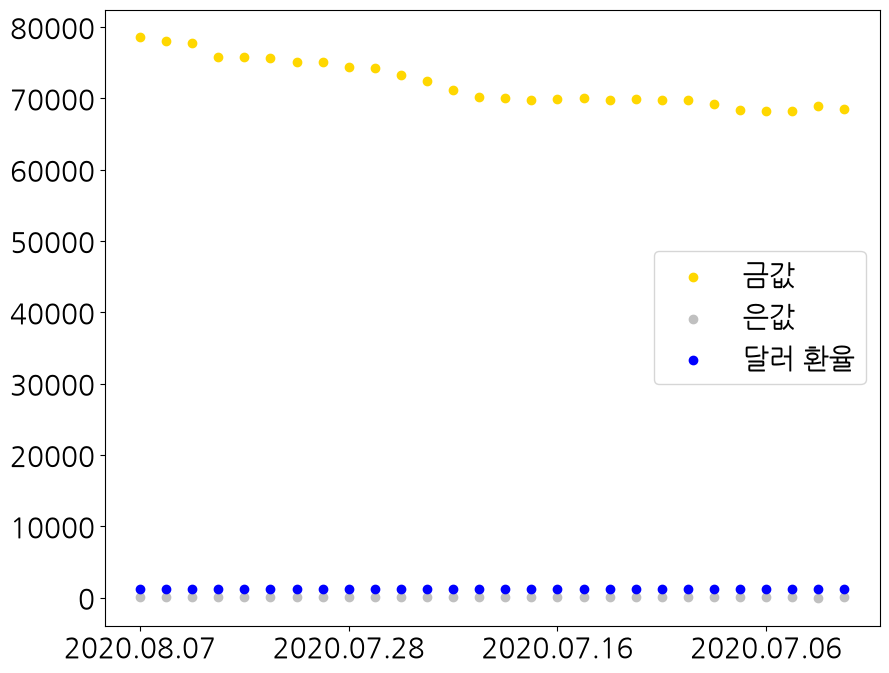

In [10]:
plt.scatter(df['일자'], df['금값'], label = '금값', color = 'gold')
plt.scatter(df['일자'], df['은값'], label = '은값', color = 'silver')
plt.scatter(df['일자'], df['달러 환율'], label = '달러 환율', color = 'blue')
plt.xticks(df['일자'].iloc[::8])
plt.legend()
plt.show()

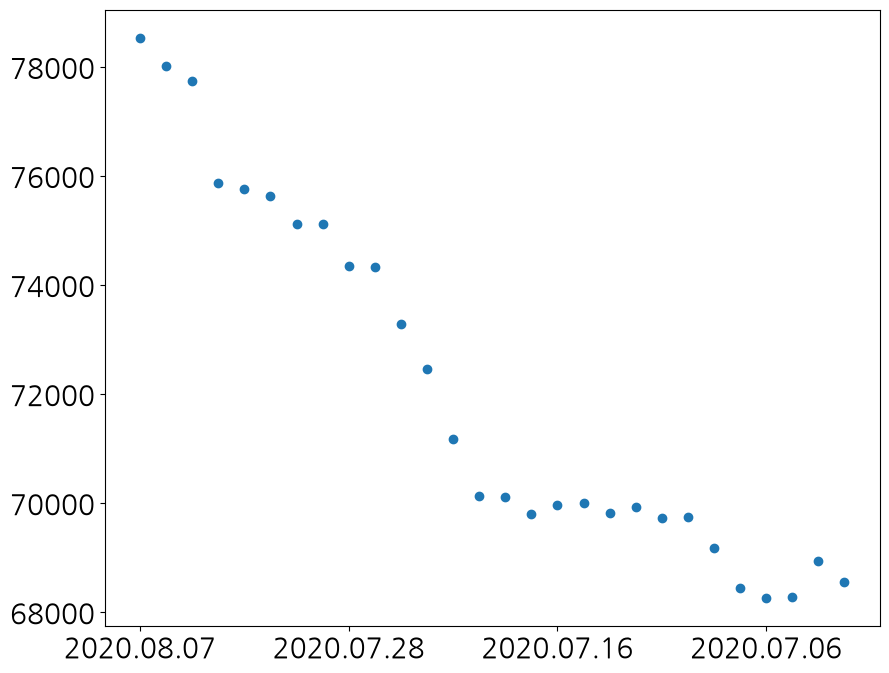

In [16]:
plt.scatter(df['일자'], df['금값'])
#plt.scatter(df['일자'], df['은값'])
#plt.scatter(df['일자'], df['달러 환율'])
plt.xticks(df['일자'].iloc[::8])
plt.show()

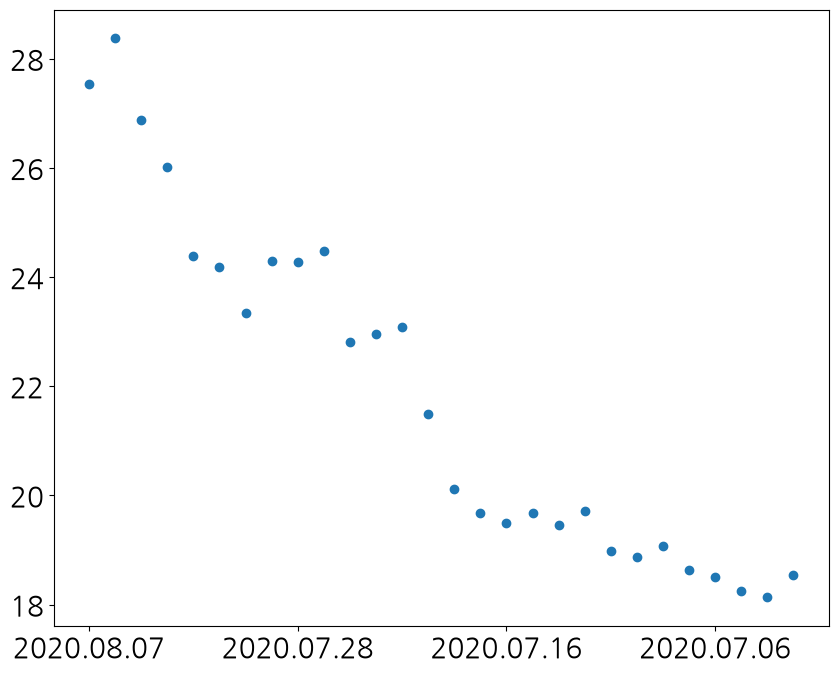

In [17]:
plt.scatter(df['일자'], df['은값'])
#plt.scatter(df['일자'], df['달러 환율'])
plt.xticks(df['일자'].iloc[::8])
plt.show()

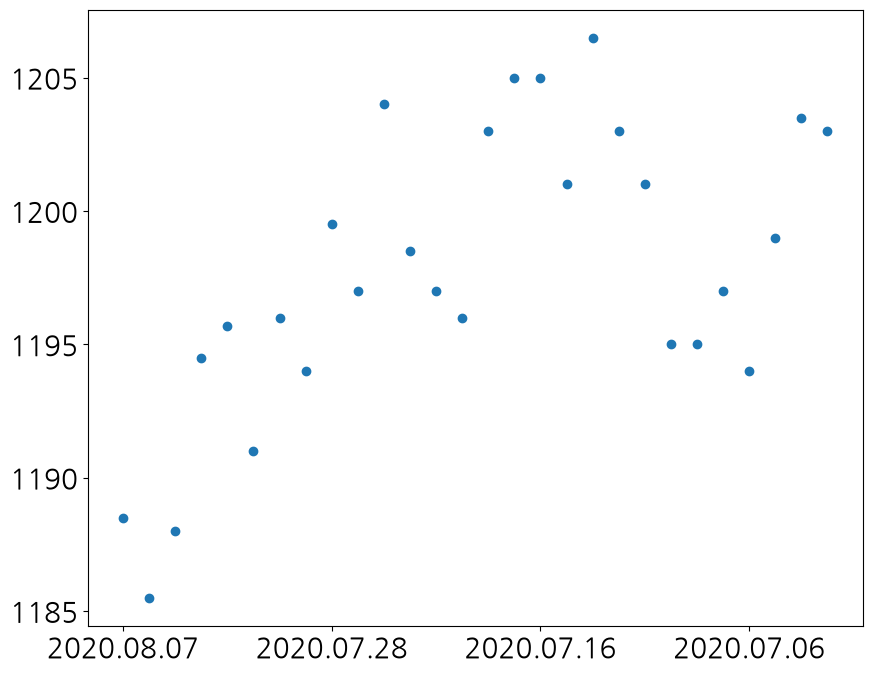

In [18]:
plt.scatter(df['일자'], df['달러 환율'])
plt.xticks(df['일자'].iloc[::8])
plt.show()

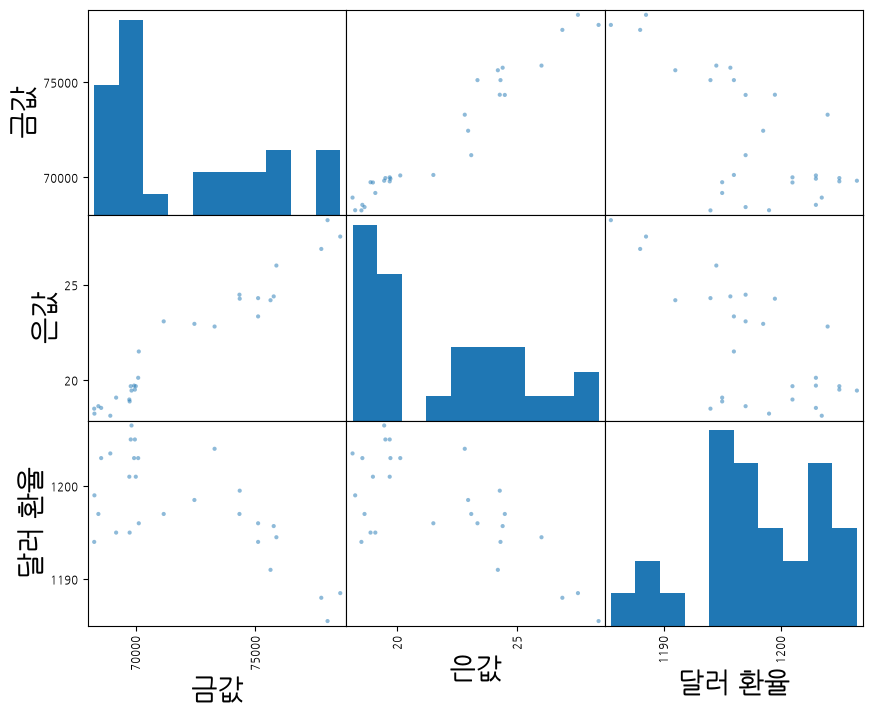

In [19]:
# scatter matirx
pd.plotting.scatter_matrix(df.drop('일자', axis = 1))
plt.show()

# 피어슨 상관계수

In [20]:
from scipy import stats
print(stats.pearsonr(df['금값'], df['은값']))
print(stats.pearsonr(df['금값'], df['달러 환율']))
print(stats.pearsonr(df['은값'], df['달러 환율']))

PearsonRResult(statistic=np.float64(0.9718640116033495), pvalue=np.float64(7.508878356557701e-18))
PearsonRResult(statistic=np.float64(-0.6793266264341936), pvalue=np.float64(7.033325258452313e-05))
PearsonRResult(statistic=np.float64(-0.6954569556203561), pvalue=np.float64(3.989042061957927e-05))


- p_value <0.05 --> 금, 은은 상관 관계 있음.
- p_value <0.05 --> 금, 달러는 상관 관계 있음.
- p_value <0.05 --> 은, 달러는 상관 관계 있음.

[해석] statistics가 양의 값: 양의 상관관계, 음의 값: 음의 상관관계.

- 금값, 은값 : 강력한 양의 상관관계
- 금값, 달러 : 음의 상관계
- 은값, 달러 : 음의 상관계